# r.noaa.atlas14

This notebook runs the examples from the *r.noaa.atlas14* manual page and visualizes the output. The tool downloads and imports [NOAA Atlas 14](https://hdsc.nws.noaa.gov/pfds/) precipitation-frequency data and supports two acquisition modes:

- **mode=point** queries the NOAA Precipitation Frequency Data Server (PFDS) for one or more longitude/latitude pairs and writes the estimates as JSON or CSV, optionally as a GRASS vector point map.
- **mode=grid** discovers, downloads, and imports NOAA Atlas 14 GIS-compatible grid archives, rescaling them to the requested statistic/units.

Capabilities demonstrated below:

| Capability | Where |
|---|---|
| Point query to JSON + vector map | Point mode |
| Depth-duration-frequency curves | Point mode |
| Intensity, CSV output, custom separator | Point mode |
| Confidence bounds (`bound=all`) | Point mode |
| Multiple points in one call | Point mode |
| Region-center fallback (no coordinates) | Point mode |
| List archives without downloading (`-l`) | Grid mode |
| Import + rescaled units, title, and history | Grid mode |
| Intensity rescaling | Grid mode |
| Filtered batch import + manifest | Grid mode |

## Setup

We use the NC SPM sample project and run in a temporary mapset.

In [1]:
import json
import os
import subprocess
import sys

# Ask GRASS where its Python packages are.
sys.path.append(
    subprocess.check_output(["grass", "--config", "python_path"], text=True).strip()
)

import pandas as pd
import matplotlib.pyplot as plt
import grass.script as gs
import grass.jupyter as gj

gj.init("~/grassdata/nc_spm_full_v2alpha2/PERMANENT")

# Create and switch to a throwaway mapset for this notebook run.
tmp_mapset = f"tmp_noaa_atlas14_{os.getpid()}"
gs.run_command("g.mapset", flags="c", mapset=tmp_mapset)
gs.run_command("g.region", raster="elevation")

## Point mode: PFDS query for Raleigh, NC

Fetch the expected precipitation depth for downtown Raleigh and write both JSON and a GRASS vector point map that carries the full tables as JSON attributes.

In [2]:
gs.run_command(
    "r.noaa.atlas14",
    mode="point",
    coordinates="-78.6382,35.7796",
    statistic="depth",
    units="english",
    series="pds",
    bound="expected",
    format="json",
    output="/tmp/raleigh_atlas14.json",
    vector_output="atlas14_raleigh",
    overwrite=True,
)

In [3]:
# Inspect the JSON payload.
with open("/tmp/raleigh_atlas14.json") as fh:
    data = json.load(fh)

print("Return periods (years):", data["table"]["return_periods_years"])
print("First few rows:")
for row in data["table"]["rows"][:5]:
    print(f"  {row['duration']:>8}  {row['values']}")

Return periods (years): [1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
First few rows:
     5-min  {'1': 0.406, '2': 0.474, '5': 0.545, '10': 0.606, '25': 0.67, '50': 0.717, '100': 0.76, '200': 0.796, '500': 0.837, '1000': 0.871}
    10-min  {'1': 0.649, '2': 0.759, '5': 0.873, '10': 0.97, '25': 1.07, '50': 1.14, '100': 1.21, '200': 1.26, '500': 1.32, '1000': 1.37}
    15-min  {'1': 0.811, '2': 0.954, '5': 1.1, '10': 1.23, '25': 1.35, '50': 1.45, '100': 1.53, '200': 1.59, '500': 1.67, '1000': 1.72}
    30-min  {'1': 1.11, '2': 1.32, '5': 1.57, '10': 1.78, '25': 2.0, '50': 2.18, '100': 2.34, '200': 2.48, '500': 2.65, '1000': 2.79}
    60-min  {'1': 1.39, '2': 1.65, '5': 2.01, '10': 2.31, '25': 2.67, '50': 2.95, '100': 3.22, '200': 3.48, '500': 3.8, '1000': 4.07}


### Depth-duration-frequency curves

Plot the expected precipitation depth against duration, one curve per return period, straight from the JSON table.

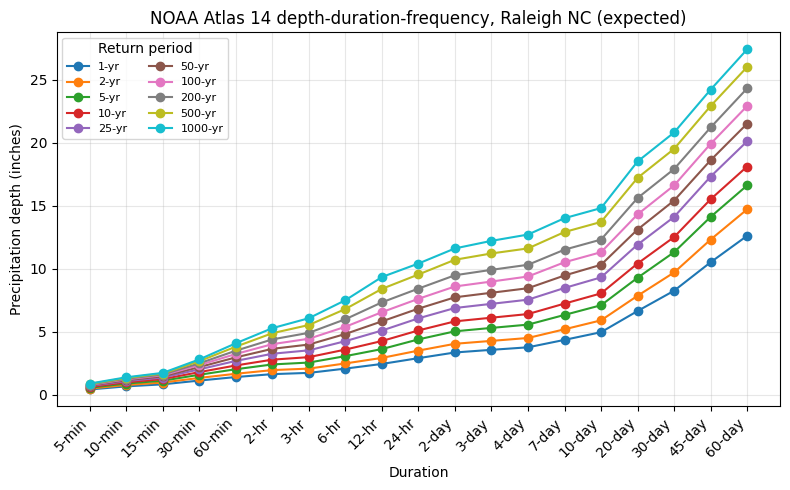

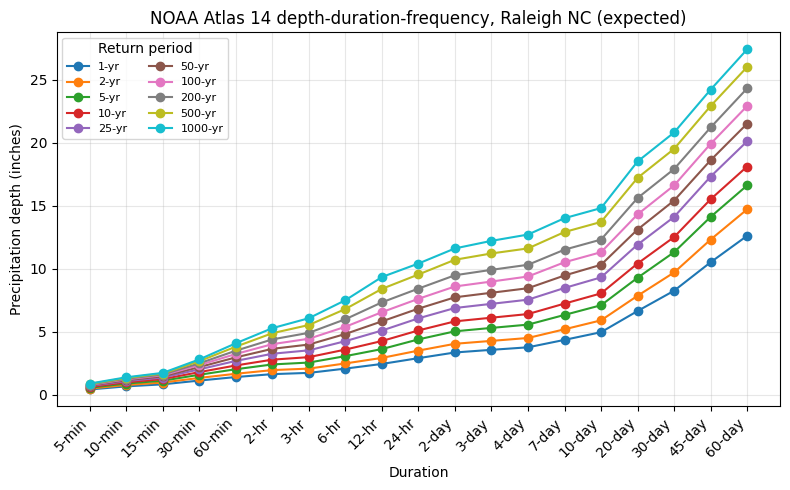

In [4]:
table = data["table"]
return_periods = table["return_periods_years"]
durations = [row["duration"] for row in table["rows"]]

fig, ax = plt.subplots(figsize=(8, 5))
for rp in return_periods:
    depths = [row["values"].get(str(rp)) for row in table["rows"]]
    ax.plot(range(len(durations)), depths, marker="o", label=f"{rp}-yr")

ax.set_xticks(range(len(durations)))
ax.set_xticklabels(durations, rotation=45, ha="right")
ax.set_xlabel("Duration")
ax.set_ylabel("Precipitation depth (inches)")
ax.set_title("NOAA Atlas 14 depth-duration-frequency, Raleigh NC (expected)")
ax.legend(title="Return period", ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig

### Intensity, CSV output, and a custom separator

Switch `statistic=intensity`, write tab-separated CSV, and read it back with pandas.

In [5]:
gs.run_command(
    "r.noaa.atlas14",
    mode="point",
    coordinates="-78.6382,35.7796",
    statistic="intensity",
    units="english",
    series="pds",
    bound="expected",
    format="csv",
    separator="tab",
    output="/tmp/raleigh_intensity.csv",
    overwrite=True,
)

idf = pd.read_csv("/tmp/raleigh_intensity.csv", sep="\t")
idf.head()

,duration,1,2,5,10,25,50,100,200,500,1000
0,5-min,4.87,5.69,6.54,7.27,8.04,8.60,9.12,9.55,10.00,10.50
1,10-min,3.89,4.55,5.24,5.82,6.41,6.85,7.25,7.57,7.94,8.23
2,15-min,3.24,3.82,4.42,4.90,5.41,5.78,6.10,6.37,6.66,6.88
3,30-min,2.22,2.63,3.14,3.55,4.01,4.36,4.68,4.96,5.30,5.57
4,60-min,1.39,1.65,2.01,2.31,2.67,2.95,3.22,3.48,3.80,4.07


### Confidence bounds

`bound=all` returns the expected value plus the upper and lower bounds of the 90% confidence interval. Here we compare the 100-year, 24-hour estimate across the three bounds.

In [6]:
bounds_json = gs.read_command(
    "r.noaa.atlas14",
    mode="point",
    coordinates="-78.6382,35.7796",
    statistic="depth",
    bound="all",
    format="json",
    flags="c",
)
bounds = json.loads(bounds_json)
for section in ("expected", "upper", "lower"):
    rows = bounds["tables"][section]["rows"]
    row24 = next(r for r in rows if "24-hr" in r["duration"])
    print(f"{section:>8}: 100-yr 24-hr = {row24['values']['100']} in")

expected: 100-yr 24-hr = 7.6 in
   upper: 100-yr 24-hr = 8.2 in
   lower: 100-yr 24-hr = 6.99 in


### Multiple points in one call

Pass several `lon,lat` pairs (Raleigh, Charlotte, Wilmington). The CSV gains `lon,lat,bound` columns, and the vector map gets one feature per point with the per-point JSON tables as attributes.

In [7]:
gs.run_command(
    "r.noaa.atlas14",
    mode="point",
    coordinates="-78.6382,35.7796,-80.8431,35.2271,-77.8868,34.2257",
    statistic="depth",
    bound="expected",
    format="csv",
    output="/tmp/nc_cities_idf.csv",
    vector_output="atlas14_nc_cities",
    overwrite=True,
)

cities = pd.read_csv("/tmp/nc_cities_idf.csv")
n_points = cities[["lon", "lat"]].drop_duplicates().shape[0]
print("CSV rows:", len(cities), "| distinct points:", n_points)
cities.head()

CSV rows: 57 | distinct points: 3


,lon,lat,bound,duration,1,2,5,10,25,50,100,200,500,1000
0,-78.6382,35.7796,expected,5-min,0.406,0.474,0.545,0.606,0.67,0.717,0.76,0.796,0.837,0.871
1,-78.6382,35.7796,expected,10-min,0.649,0.759,0.873,0.970,1.07,1.140,1.21,1.260,1.320,1.370
2,-78.6382,35.7796,expected,15-min,0.811,0.954,1.100,1.230,1.35,1.450,1.53,1.590,1.670,1.720
3,-78.6382,35.7796,expected,30-min,1.110,1.320,1.570,1.780,2.00,2.180,2.34,2.480,2.650,2.790
4,-78.6382,35.7796,expected,60-min,1.390,1.650,2.010,2.310,2.67,2.950,3.22,3.480,3.800,4.070


In [8]:
# The vector map carries one feature per queried point.
print(
    gs.read_command(
        "v.db.select", map="atlas14_nc_cities", columns="cat,lon,lat", format="csv"
    )
)

cat,lon,lat
1,-78.6382,35.7796
2,-80.8431,35.2271
3,-77.8868,34.2257



### Region-center fallback

With no `coordinates=`, the tool queries the center of the current computational region, reprojecting the region bounds to WGS84 lon/lat so it works from any project CRS.

In [9]:
gs.run_command("g.region", raster="elevation")
center_json = gs.read_command(
    "r.noaa.atlas14", mode="point", format="json", bound="expected", flags="c"
)
center = json.loads(center_json)
print("Queried lon/lat:", center["request"]["lon"], center["request"]["lat"])
print("Request URL:", center["request"]["url"])

Queried lon/lat: -78.691461835 35.74855834
Request URL: https://hdsc.nws.noaa.gov/cgi-bin/new/fe_text.csv?lat=35.74855834&lon=-78.691461835&data=depth&units=english&series=pds


## Grid mode

North Carolina falls in NOAA Atlas 14 Volume 2 (Ohio River Basin and surrounding states), region code `orb`, so we use that volume below.

### List matching archives without downloading

The `-l` flag reports which archives match the filters (as JSON lines) so you can scope a download before committing to it.

In [10]:
listing = gs.read_command(
    "r.noaa.atlas14",
    mode="grid",
    region="orb",
    durations="24hr",
    aris="2,10,100",
    bound="expected",
    flags="l",
)
matches = [json.loads(line) for line in listing.splitlines() if line.strip()]
print("matching archives:", len(matches))
for m in matches:
    print(
        f"  {m['filename']:>18}  ari={m['ari']}  dur={m['duration']}  bound={m['bound']}"
    )

matching archives: 3
      orb2yr24ha.zip  ari=2  dur=24hr  bound=expected
     orb10yr24ha.zip  ari=10  dur=24hr  bound=expected
    orb100yr24ha.zip  ari=100  dur=24hr  bound=expected


### Import a single archive

Download one archive directly by URL and import the rescaled raster (depth in inches) with `-i` (uses *r.import* so it is reprojected into the NC SPM project). The full grid extent is imported regardless of the current region.

In [11]:
gs.run_command(
    "r.noaa.atlas14",
    mode="grid",
    archive_url="https://hdsc.nws.noaa.gov/pub/hdsc/data/orb/orb100yr24ha.zip",
    output_prefix="a14",
    flags="i",
    overwrite=True,
)

In [12]:
raster_name = gs.list_grouped(type="raster", pattern="a14_*")[gs.gisenv()["MAPSET"]][0]
print("Imported:", raster_name)

# r.info shows the rescaled units and the descriptive title set by the tool.
info = gs.raster_info(raster_name)
print("units:", info["units"], "| title:", info["title"])
print("min/max (inches):", round(info["min"], 3), round(info["max"], 3))

Imported: a14_depth_expected_24hr_100yr_english_pds_orb
units: inches | title: "NOAA Atlas 14 depth (expected) 24hr 100-yr ARI"
min/max (inches): 4.157 14.295


In [13]:
# Processing history is recorded on the output raster.
print(gs.read_command("r.info", map=raster_name, flags="h"))

Data Source:
   
   
Data Description:
   generated by r.mapcalc
Comments:
   r.noaa.atlas14 --o -i mode=grid archive_url=https://hdsc.nws.noaa.gov/pub/hdsc/
   data/orb/orb100yr24ha.zip output_prefix=a14
   {"source_archive": "orb100yr24ha.zip", "source_file": "orb100yr24ha.asc
   ", "parsed": {"url": "", "filename": "orb100yr24ha.asc", "region": "orb
   ", "bound": "expected", "statistic": "depth", "units": "english", "seri
   es": "pds", "duration": "24hr", "ari": 100}, "output_statistic": "depth
   ", "output_units": "english", "unit_label": "inches"}



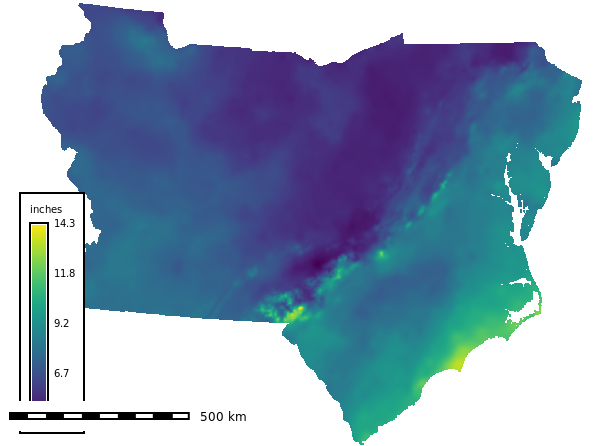

In [14]:
gs.run_command("g.region", raster=raster_name)
grid_map = gj.Map(use_region=True)
grid_map.d_rast(map=raster_name)
grid_map.d_legend(raster=raster_name, at=(5, 50, 5, 8), flags="b")
grid_map.d_barscale()
grid_map.show()

### Intensity rescaling

Re-import the same archive with `statistic=intensity`. NOAA only publishes depth, so the tool divides by the duration to produce in/hr automatically.

In [15]:
gs.run_command(
    "r.noaa.atlas14",
    mode="grid",
    archive_url="https://hdsc.nws.noaa.gov/pub/hdsc/data/orb/orb100yr24ha.zip",
    statistic="intensity",
    units="english",
    output_prefix="a14int",
    flags="i",
    overwrite=True,
)
intensity_rast = gs.list_grouped(type="raster", pattern="a14int_*")[
    gs.gisenv()["MAPSET"]
][0]
iinfo = gs.raster_info(intensity_rast)
print(intensity_rast)
print(
    "units:",
    iinfo["units"],
    "| min/max (in/hr):",
    round(iinfo["min"], 5),
    round(iinfo["max"], 5),
)

a14int_intensity_expected_24hr_100yr_english_pds_orb
units: inches/hr | min/max (in/hr): 0.17321 0.59562


### Filtered batch import with a manifest

Autodiscover the `orb` volume, filter to a duration and a couple of recurrence intervals, and write a manifest CSV describing every imported raster.

In [16]:
gs.run_command(
    "r.noaa.atlas14",
    mode="grid",
    region="orb",
    durations="12hr",
    aris="10,100",
    bound="expected",
    output_prefix="batch",
    output="/tmp/a14_manifest.csv",
    flags="i",
    overwrite=True,
)
manifest = pd.read_csv("/tmp/a14_manifest.csv")
manifest[["map", "duration", "ari", "statistic", "units", "region"]]

,map,duration,ari,statistic,units,region
0,batch_depth_expected_12hr_10yr_english_pds_orb,12hr,10,depth,english,orb
1,batch_depth_expected_12hr_100yr_english_pds_orb,12hr,100,depth,english,orb


### Clean up

Remove the temporary mapset created for this run.

In [17]:
gs.run_command("g.mapset", mapset="PERMANENT")
gs.run_command("g.mapsets", operation="remove", mapset=tmp_mapset)
# To fully delete it, remove its directory from the project on disk.